In [249]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

In [250]:
for p in sys.path:
    print(p)

/home/vay3059/desktop/SURG-Mars/project/tests/actual
/opt/anaconda3/lib/python312.zip
/opt/anaconda3/lib/python3.12
/opt/anaconda3/lib/python3.12/lib-dynload

/home/vay3059/.local/lib/python3.12/site-packages
/opt/anaconda3/lib/python3.12/site-packages
/home/vay3059/desktop/SURG-Mars/project


In [251]:
data_path = '../../data/1999-09-20-mw77-taiwan'
files = [f for f in os.listdir(data_path) if f.endswith('.SAC')]
streams = [read(data_path + '/' + f) for f in files]
traces = [st[0] for st in streams if len(st) == 1]
assert len(traces) == len(files), "Some files contain more than one trace."
traces_dict = defaultdict(list)
for tr in traces:
    traces_dict[tr.stats.station].append(tr)
for station in traces_dict:
    print(f'Station {station}, {traces_dict[station][0].stats.sac.dist: .2f} km, {len(traces_dict[station])} trace(s).')

Station GNI,  7200.19 km, 3 trace(s).
Station TLY,  3422.55 km, 3 trace(s).
Station BFO,  9591.24 km, 3 trace(s).
Station AFI,  8421.05 km, 6 trace(s).
Station XMAS,  9069.85 km, 6 trace(s).
Station JOHN,  7239.78 km, 6 trace(s).
Station HIA,  2822.81 km, 3 trace(s).
Station PET,  4530.93 km, 3 trace(s).
Station WRAB,  5054.89 km, 6 trace(s).
Station CASY,  10028.16 km, 6 trace(s).
Station MAKZ,  4289.97 km, 6 trace(s).
Station ARU,  6137.75 km, 3 trace(s).
Station KBS,  7817.34 km, 3 trace(s).
Station CTAO,  5580.89 km, 3 trace(s).


In [252]:
name = 'XMAS'
sta = traces_dict[name]
sta[0].stats

         network: IU
         station: XMAS
        location: 01
         channel: BHZ
       starttime: 1999-09-20T17:57:33.010092Z
         endtime: 1999-09-20T18:11:44.985092Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 34080
           calib: 8388520000.0
         _format: SAC
             sac: AttribDict({'delta': 0.025, 'scale': 8388520000.0, 'b': 9.2e-05, 'e': 851.9751, 'o': -617.01013, 'stla': 2.0448, 'stlo': -157.4457, 'stel': 19.0, 'stdp': 1.0, 'evla': 23.85, 'evlo': 120.87, 'evdp': 13.2, 'dist': 9069.846, 'az': 91.486626, 'baz': 293.6699, 'gcarc': 81.570694, 'cmpaz': 0.0, 'cmpinc': 0.0, 'nzyear': 1999, 'nzjday': 263, 'nzhour': 17, 'nzmin': 57, 'nzsec': 33, 'nzmsec': 10, 'nvhdr': 6, 'npts': 34080, 'iftype': 1, 'leven': 1, 'kstnm': 'XMAS', 'kevnm': 'Taiwan', 'khole': '01', 'kcmpnm': 'BHZ', 'knetwk': 'IU', 'kinst': 'Streckei'})

In [253]:
loc = '00'
if len(sta) > 3:
    sta = [tr for tr in sta if tr.stats.location == loc]

Original back-azimuth: 293.67


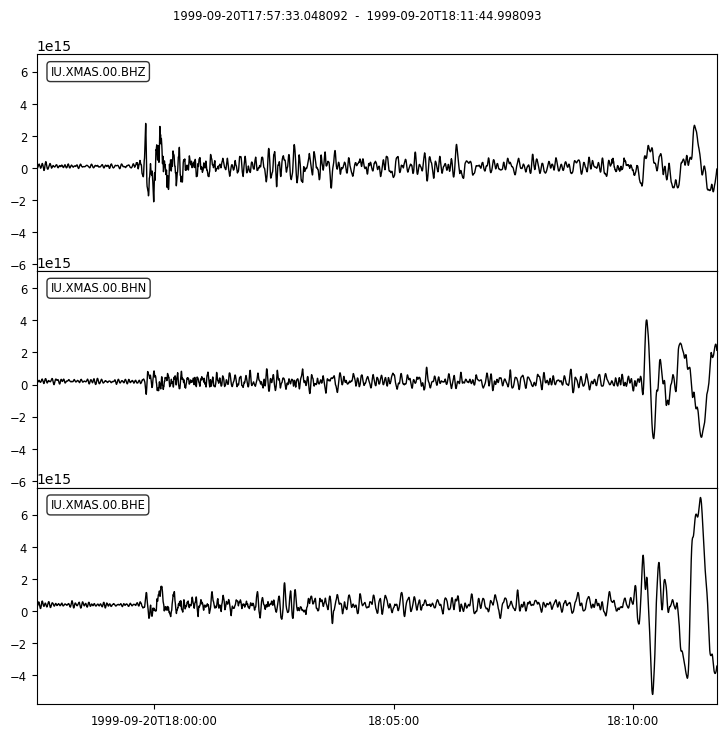

In [254]:
st = Stream(sta)
baz = st[0].stats.sac.baz
print(f'Original back-azimuth: {baz:.2f}')
st.plot();

In [255]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

hdepth = 13.2  # km
alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 13.2 km, P velocity = 5.8 km/s, S velocity = 3.46 km/s


In [256]:
eq_lat = 23.85
eq_lon = 120.87
print(f'Earthquake coordinates: lat {eq_lat}, lon {eq_lon}')
sta_lat = sta[0].stats.sac.stla
sta_lon = sta[0].stats.sac.stlo
print(f'Station coordinates: lat {sta_lat:.2f}, lon {sta_lon:.2f}')
event_locs = [eq_lat, eq_lon, sta_lat, sta_lon]
dist, az_check, baz_check = gps2dist_azimuth(*event_locs)
epdist = kilometers2degrees(dist/1000)
print(f'Distance between event and station: {dist/1000:.2f} km, {epdist:.2f} degrees')
print(f'Azimuth: {az_check:.2f}, Back-azimuth: {baz_check:.2f}')

Earthquake coordinates: lat 23.85, lon 120.87
Station coordinates: lat 2.04, lon -157.45
Distance between event and station: 9077.88 km, 81.64 degrees
Azimuth: 91.39, Back-azimuth: 293.73


In [ ]:
p_arrival = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist, phase_list=['P'])[0]
s_arrival = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                    distance_in_degree=epdist, phase_list=['S'])[0]
p_inc = p_arrival.incident_angle
s_inc = s_arrival.incident_angle
print(f'Incidence angles: P = {p_inc:.2f}, S = {s_inc:.2f}')

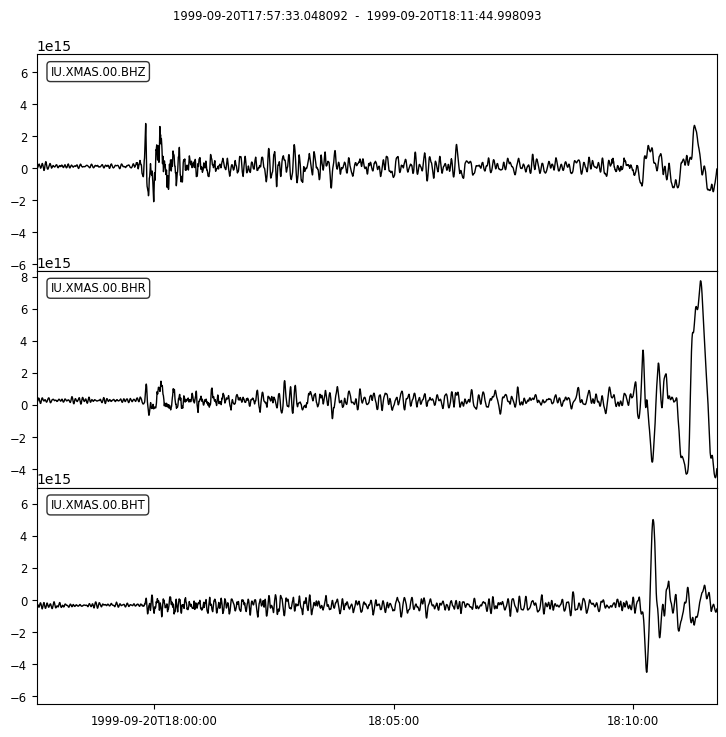

In [258]:
st_RT = st.copy()
st_RT.rotate('NE->RT', back_azimuth=baz)
st_RT.plot();

In [259]:
st_P = st.copy()
st_P.rotate('ZNE->LQT', back_azimuth=baz, inclination=p_inc)
st_S = st.copy()
st_S.rotate('ZNE->LQT', back_azimuth=baz, inclination=s_inc)

3 Trace(s) in Stream:
IU.XMAS.00.BHL | 1999-09-20T17:57:33.048093Z - 1999-09-20T18:11:44.998093Z | 20.0 Hz, 17040 samples
IU.XMAS.00.BHT | 1999-09-20T17:57:33.048092Z - 1999-09-20T18:11:44.998092Z | 20.0 Hz, 17040 samples
IU.XMAS.00.BHQ | 1999-09-20T17:57:33.048092Z - 1999-09-20T18:11:44.998092Z | 20.0 Hz, 17040 samples

In [260]:
st_P[0].stats

         network: IU
         station: XMAS
        location: 00
         channel: BHL
       starttime: 1999-09-20T17:57:33.048093Z
         endtime: 1999-09-20T18:11:44.998093Z
   sampling_rate: 20.0
           delta: 0.05
            npts: 17040
           calib: 8388110000.0
         _format: SAC
    back_azimuth: 293.6699
     inclination: 15.98660475811795
             sac: AttribDict({'delta': 0.05, 'scale': 8388110000.0, 'b': 9.3e-05, 'e': 851.9501, 'o': -617.04803, 'stla': 2.0448, 'stlo': -157.4457, 'stel': 19.0, 'stdp': 1.0, 'evla': 23.85, 'evlo': 120.87, 'evdp': 13.2, 'dist': 9069.846, 'az': 91.486626, 'baz': 293.6699, 'gcarc': 81.570694, 'cmpaz': 0.0, 'cmpinc': 0.0, 'nzyear': 1999, 'nzjday': 263, 'nzhour': 17, 'nzmin': 57, 'nzsec': 33, 'nzmsec': 48, 'nvhdr': 6, 'npts': 17040, 'iftype': 1, 'leven': 1, 'kstnm': 'XMAS', 'kevnm': 'Taiwan', 'khole': '00', 'kcmpnm': 'BHZ', 'knetwk': 'IU', 'kinst': 'Streckei'})

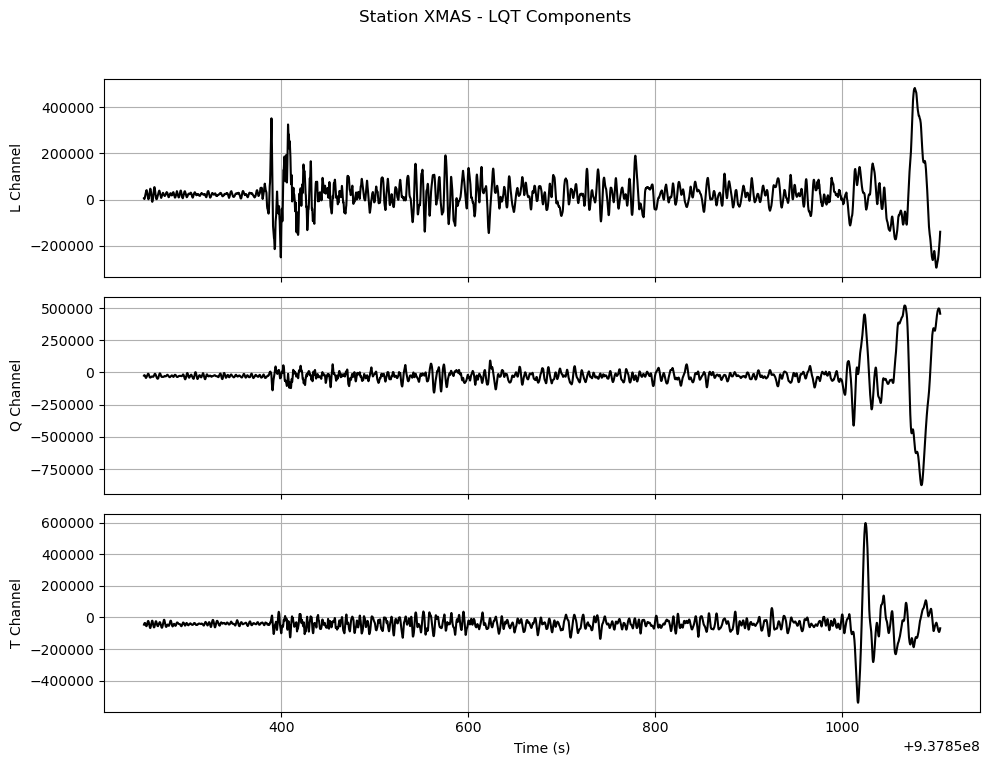

In [261]:
# make subplots of all three components L, Q, T
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True)
components = ['L', 'Q', 'T']
for i, comp in enumerate(components):
    tr = st_P.select(component=comp)[0]
    times = tr.times(type='utcdatetime')
    axes[i].plot(times, tr.data, 'k')
    axes[i].set_ylabel(f'{comp} Channel')
    axes[i].grid()
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Station {name} - LQT Components')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


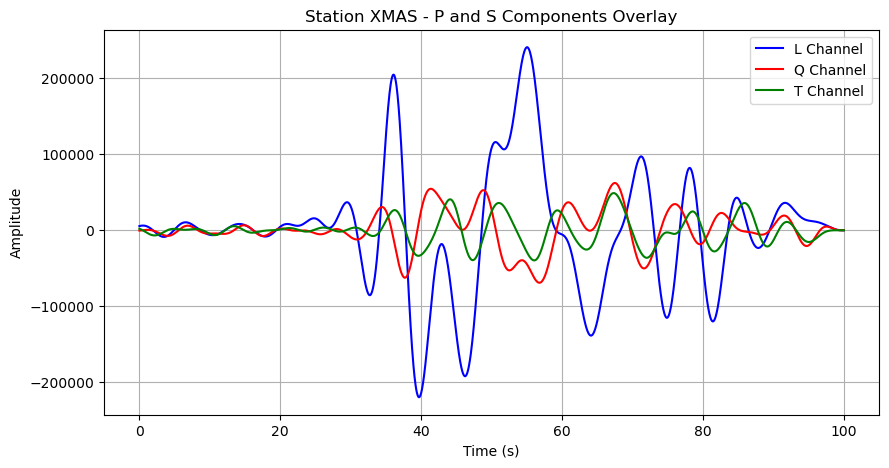

In [262]:
# overlayed plot of channels at p-arrival
fig, ax = plt.subplots(figsize=(10, 5))
tr_P = st_P.select(component='L')[0].copy()
tr_Sv = st_P.select(component='Q')[0].copy()
tr_Sh = st_P.select(component='T')[0].copy()

p_arrival = tr_P.stats.starttime + 120  # 2 minutes after start
p_start = p_arrival - 20
p_end = p_arrival + 80
tr_P = tr_P.slice(p_start, p_end)
tr_Sv = tr_Sv.slice(p_start, p_end)
tr_Sh = tr_Sh.slice(p_start, p_end)

for tr in [tr_P, tr_Sv, tr_Sh]:
    tr.detrend('linear')
    tr.detrend('demean')
    tr.filter('lowpass', freq=0.2,
              corners=4, zerophase=True)


times_P = tr_P.times(type='relative')
times_Sv = tr_Sv.times(type='relative')
times_Sh = tr_Sh.times(type='relative')
ax.plot(times_P, tr_P.data, 'b', label='L Channel')
ax.plot(times_Sv, tr_Sv.data, 'r', label='Q Channel')
ax.plot(times_Sh, tr_Sh.data, 'g', label='T Channel')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P and S Components Overlay')
ax.legend()
ax.grid()
plt.show()

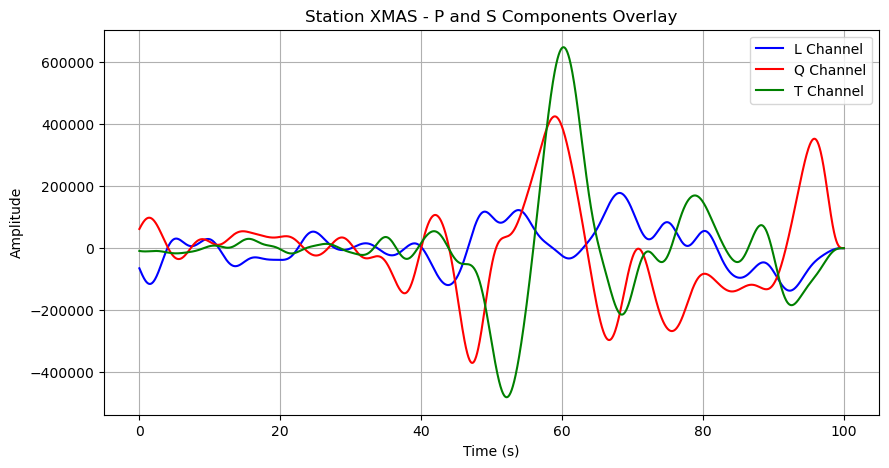

In [263]:
# overlayed plot of channels at s-arrival
fig, ax = plt.subplots(figsize=(10, 5))
tr2_P = st_S.select(component='L')[0].copy()
tr2_Sv = st_S.select(component='Q')[0].copy()
tr2_Sh = st_S.select(component='T')[0].copy()

s_arrival = tr2_Sv.stats.endtime - 120  # 2 minutes before end
s_start = s_arrival - 20
s_end = s_arrival + 80
tr2_P = tr2_P.slice(s_start, s_end)
tr2_Sv = tr2_Sv.slice(s_start, s_end)
tr2_Sh = tr2_Sh.slice(s_start, s_end)

for tr in [tr2_P, tr2_Sv, tr2_Sh]:
    tr.detrend('linear')
    tr.detrend('demean')
    tr.filter('lowpass', freq=0.2,
              corners=4, zerophase=True)
    
times2_P = tr2_P.times(type='relative')
times2_Sv = tr2_Sv.times(type='relative')
times2_Sh = tr2_Sh.times(type='relative')
ax.plot(times2_P, tr2_P.data, 'b', label='L Channel')
ax.plot(times2_Sv, tr2_Sv.data, 'r', label='Q Channel')
ax.plot(times2_Sh, tr2_Sh.data, 'g', label='T Channel')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P and S Components Overlay')
ax.legend()
ax.grid()
plt.show()